# IS 477 Project Code

In [32]:
# main
import pandas as pd
import numpy as np
import re

# plotting
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [33]:
os.chdir('/workspaces/LG')

In [34]:
dfCrashes = pd.read_csv("data/raw/crashes.csv")
dfPeople = pd.read_csv("data/raw/people.csv")

/tmp/ipykernel_2395/896320708.py:2: DtypeWarning: Columns (0: vehicle_id, 1: age, 2: bac_result, 3: cell_phone_use, 4: bac_result_value) have mixed types. Specify dtype option on import or set low_memory=False.
  dfPeople = pd.read_csv("data/raw/people.csv")


In [35]:
print("The crashes dataset has", dfCrashes.shape[1], "columns and", dfCrashes.shape[0], "rows.")
print("The people dataset has", dfPeople.shape[1], "columns and", dfPeople.shape[0], "rows.")

The crashes dataset has 20 columns and 1045043 rows.
The people dataset has 16 columns and 2293745 rows.


In [36]:
dfPeople['age'] = pd.to_numeric(dfPeople['age'], errors = 'coerce')
dfPeopleAgg = dfPeople.groupby('crash_record_id').agg(age_mean = ('age', 'mean'), num_people = ('person_id', 'count')).reset_index()

In [37]:
dfPeopleAgg['any_alcohol'] = (
    dfPeople[dfPeople['bac_result'] == 'POSITIVE']
    .groupby('crash_record_id')
    .size()
    .reindex(dfPeopleAgg['crash_record_id'], fill_value = 0)
    .gt(0)
    .astype(int)
    .values
)

In [38]:
dfMain = dfCrashes.merge(dfPeopleAgg, on = 'crash_record_id', how = 'left')

In [39]:
dfMain.head()

,crash_record_id,crash_date,posted_speed_limit,traffic_control_device,weather_condition,lighting_condition,roadway_surface_cond,road_defect,crash_type,damage,...,injuries_fatal,injuries_incapacitating,crash_hour,crash_day_of_week,crash_month,latitude,longitude,age_mean,num_people,any_alcohol
0,000013b0123279411e0ec856dae95ab9f0851764350b7f...,2020-11-16T13:50:00.000,35,NO CONTROLS,CLEAR,DAYLIGHT,DRY,UNKNOWN,NO INJURY / DRIVE AWAY,"$501 - $1,500",...,0.0,0.0,13,2,11,41.844584,-87.695360,51.0,1.0,0.0
1,00002c0771fb6f2c70ba775b7f6b501608cadea85c1dd1...,2016-04-16T05:49:00.000,30,TRAFFIC SIGNAL,CLEAR,DAWN,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,"OVER $1,500",...,0.0,0.0,5,7,4,41.844734,-87.695363,35.0,2.0,0.0
2,000043c6564ec4d54bc4efd957d97ca97f38a965dd64b4...,2019-12-22T02:11:00.000,30,NO CONTROLS,CLEAR,"DARKNESS, LIGHTED ROAD",DRY,NO DEFECTS,INJURY AND / OR TOW DUE TO CRASH,"OVER $1,500",...,0.0,0.0,2,1,12,41.691319,-87.540255,NaN,1.0,0.0
3,00005696946846c8b8a1d378dba4e2a5ed84a9b2876fe0...,2024-02-02T09:48:00.000,30,NO CONTROLS,CLEAR,DAYLIGHT,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,"OVER $1,500",...,0.0,0.0,9,6,2,41.811261,-87.606750,54.0,1.0,0.0
4,000070ed7a6357c3298f5edc6fb7d5ce925a10f46660f3...,2016-10-24T02:42:00.000,35,NO CONTROLS,CLEAR,"DARKNESS, LIGHTED ROAD",DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,"$501 - $1,500",...,0.0,0.0,2,2,10,41.873272,-87.695937,47.5,2.0,0.0


## Data Cleaning - Ganga

In [40]:
# general overview of dataset columns and corresponding data types
dfMain.info()

<class 'pandas.DataFrame'>
RangeIndex: 1045043 entries, 0 to 1045042
Data columns (total 23 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   crash_record_id          1045043 non-null  str    
 1   crash_date               1045043 non-null  str    
 2   posted_speed_limit       1045043 non-null  int64  
 3   traffic_control_device   1045043 non-null  str    
 4   weather_condition        1045043 non-null  str    
 5   lighting_condition       1045043 non-null  str    
 6   roadway_surface_cond     1045043 non-null  str    
 7   road_defect              1045043 non-null  str    
 8   crash_type               1045043 non-null  str    
 9   damage                   1045043 non-null  str    
 10  prim_contributory_cause  1045043 non-null  str    
 11  num_units                1045043 non-null  int64  
 12  injuries_total           1042790 non-null  float64
 13  injuries_fatal           1042790 non-null  float64
 1

In [41]:
# drop person-level columns not included in the merged dataset
cols_to_drop = ['driver_action', 'driver_vision', 'physical_condition', 'ejection', 'airbag_deployed', 'safety_equipment', 'bac_result']
dfMain = dfMain.drop(columns=[c for c in cols_to_drop if c in dfMain.columns])

In [42]:
# condensing 'injuries_total', 'injuries_fatal', and 'injuries_incapacitating' to binary injury marker
dfMain = dfMain.dropna(subset = ['injuries_total', 'injuries_fatal', 'injuries_incapacitating'])
dfMain['severe'] = (dfMain['injuries_total'] > 0).astype(int)
print(f"Severe crash rate after fix: {dfMain['severe'].mean():.1%}")
print(f"Shape after dropping nulls: {dfMain.shape}")

Severe crash rate after fix: 14.4%
Shape after dropping nulls: (1042790, 24)


In [43]:
# filter out improbable speed limit values
invalid_speeds = list(range(0, 10)) + [99]
dfMain['posted_speed_limit'] = dfMain['posted_speed_limit'].replace(invalid_speeds, pd.NA)
dfMain['posted_speed_limit'] = dfMain['posted_speed_limit'].fillna(dfMain['posted_speed_limit'].median())

In [44]:
# function to only keep top n_keep values from rare categories
def collapse_rare(series, n_keep = 10, other_label = 'OTHER'):
    top = series.value_counts().head(n_keep).index
    return series.where(series.isin(top), other_label)

dfMain['prim_contributory_cause'] = collapse_rare(dfMain['prim_contributory_cause'], n_keep = 14)
dfMain['traffic_control_device'] = collapse_rare(dfMain['traffic_control_device'], n_keep = 4)
dfMain['weather_condition'] = collapse_rare(dfMain['weather_condition'], n_keep = 5)
dfMain['road_defect'] = collapse_rare(dfMain['road_defect'], n_keep = 2)

In [45]:
# constant value imputation for categorical null values
cat_cols = dfMain.select_dtypes('category').columns
for col in cat_cols:
    if dfMain[col].isna().any():
        if 'UNKNOWN' not in dfMain[col].cat.categories:
            dfMain[col] = dfMain[col].cat.add_categories('UNKNOWN')
        dfMain[col] = dfMain[col].fillna('UNKNOWN')

# simple imputation for numeric null values
dfMain['latitude'] = dfMain['latitude'].fillna(dfMain['latitude'].median())
dfMain['longitude'] = dfMain['longitude'].fillna(dfMain['longitude'].median())
dfMain['age_mean'] = dfMain['age_mean'].fillna(dfMain['age_mean'].median())
dfMain['any_alcohol'] = dfMain['any_alcohol'].fillna(0)

# define new binary column 'severe' to indicate if there is at least 1 total injury associated with each crash
dfMain['severe'] = (dfMain['injuries_total'] > 0).astype(int)

In [46]:
print(f"Shape: {dfMain.shape}")
print(f"Duplicate crash IDs: {dfMain['crash_record_id'].duplicated().sum()}")
print(f"Nulls remaining:\n{dfMain.isnull().sum()[dfMain.isnull().sum() > 0]}")
print(f"Severe crash rate: {dfMain['severe'].mean():.1%}")
print(f"Speed limit distribution after cleaning:\n{dfMain['posted_speed_limit'].value_counts().sort_index()}")

Shape: (1042790, 24)
Duplicate crash IDs: 3753
Nulls remaining:
Series([], dtype: int64)
Severe crash rate: 14.4%
Speed limit distribution after cleaning:
posted_speed_limit
10     24857
11        11
12         7
14         7
15     36932
16         1
18         3
20     43977
22         5
23         3
24        39
25     68550
26        16
29         3
30    783379
31         3
32        22
33        15
34        18
35     66569
36         8
38         2
39       107
40     10071
44         1
45      6745
46         1
49         1
50       326
55      1019
60        61
62         1
63         1
65        21
70         8
Name: count, dtype: int64


In [47]:
# convert crash_date to datetime so we can use time-based features later
dfMain['crash_date'] = pd.to_datetime(dfMain['crash_date'])

# convert posted_speed_limit to numeric
dfMain['posted_speed_limit'] = pd.to_numeric(dfMain['posted_speed_limit'], errors='coerce').astype(int)

In [48]:
# calculate the percentage of missing values per column
missing = (dfMain.isna().sum() / len(dfMain) * 100).round(2)

# highlight columns with missing values, sorted from most to least missing
print(missing[missing > 0].sort_values(ascending = False))

Series([], dtype: float64)


In [49]:
# convert remaining cateogrical columns to pandas category type for faster computation
str_cols = ['traffic_control_device', 'weather_condition', 'lighting_condition', 'roadway_surface_cond', 'road_defect', 'crash_type', 'damage', 'prim_contributory_cause']

for col in str_cols:
    dfMain[col] = dfMain[col].astype('category')

In [50]:
# final check
dfMain.info()

<class 'pandas.DataFrame'>
Index: 1042790 entries, 0 to 1045042
Data columns (total 24 columns):
 #   Column                   Non-Null Count    Dtype         
---  ------                   --------------    -----         
 0   crash_record_id          1042790 non-null  str           
 1   crash_date               1042790 non-null  datetime64[us]
 2   posted_speed_limit       1042790 non-null  int64         
 3   traffic_control_device   1042790 non-null  category      
 4   weather_condition        1042790 non-null  category      
 5   lighting_condition       1042790 non-null  category      
 6   roadway_surface_cond     1042790 non-null  category      
 7   road_defect              1042790 non-null  category      
 8   crash_type               1042790 non-null  category      
 9   damage                   1042790 non-null  category      
 10  prim_contributory_cause  1042790 non-null  category      
 11  num_units                1042790 non-null  int64         
 12  injuries_total  

## Exploratory Data Analysis - Ganga

In [51]:
# use a smaller random sample of the data for quicker computing
sample = dfMain.sample(frac = 0.1, random_state = 42)

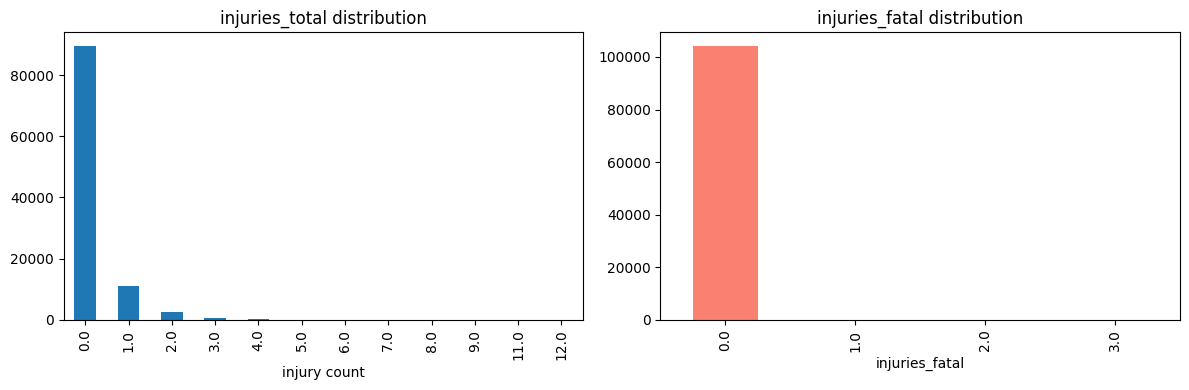

In [52]:
fig, axes = plt.subplots(1, 2, figsize = (12, 4))

sample['injuries_total'].value_counts().sort_index().head(15).plot(kind = 'bar', ax = axes[0])
axes[0].set_title('injuries_total distribution')
axes[0].set_xlabel('injury count')

sample['injuries_fatal'].value_counts().sort_index().head(10).plot(kind = 'bar', ax = axes[1], color = 'salmon')
axes[1].set_title('injuries_fatal distribution')

plt.tight_layout()
plt.show()

In [53]:
print(sample[['injuries_total','injuries_fatal']].describe())
print(f"\nZero-injury crashes: {(sample['injuries_total'] == 0).mean():.1%}")
print(f"Fatal crashes: {(sample['injuries_fatal'] > 0).mean():.1%}")

       injuries_total  injuries_fatal
count   104279.000000   104279.000000
mean         0.195629        0.001247
std          0.570969        0.038159
min          0.000000        0.000000
25%          0.000000        0.000000
50%          0.000000        0.000000
75%          0.000000        0.000000
max         12.000000        3.000000

Zero-injury crashes: 85.8%
Fatal crashes: 0.1%


In [54]:
# frequency tables for categorical variables
cat_cols = [
    'weather_condition', 'lighting_condition', 'roadway_surface_cond',
    'road_defect', 'crash_type', 'damage', 'prim_contributory_cause',
    'traffic_control_device'
]

for col in cat_cols:
    counts = sample[col].value_counts(normalize = True)
    rare = counts[counts < 0.01]
    print(f"\n{col} — {counts.shape[0]} categories, {len(rare)} rare (<1%)")
    print(counts.head(8).to_string())


weather_condition — 6 categories, 1 rare (<1%)
weather_condition
CLEAR              0.784818
RAIN               0.083200
UNKNOWN            0.060194
SNOW               0.033190
CLOUDY/OVERCAST    0.029162
OTHER              0.009436

lighting_condition — 6 categories, 0 rare (<1%)
lighting_condition
DAYLIGHT                  0.641759
DARKNESS, LIGHTED ROAD    0.217532
UNKNOWN                   0.049109
DARKNESS                  0.046807
DUSK                      0.027733
DAWN                      0.017060

roadway_surface_cond — 7 categories, 3 rare (<1%)
roadway_surface_cond
DRY                0.734271
WET                0.126862
UNKNOWN            0.095436
SNOW OR SLUSH      0.033286
ICE                0.007058
OTHER              0.002676
SAND, MUD, DIRT    0.000412

road_defect — 3 categories, 0 rare (<1%)
road_defect
NO DEFECTS    0.782775
UNKNOWN       0.198755
OTHER         0.018470

crash_type — 2 categories, 0 rare (<1%)
crash_type
NO INJURY / DRIVE AWAY              0.731029


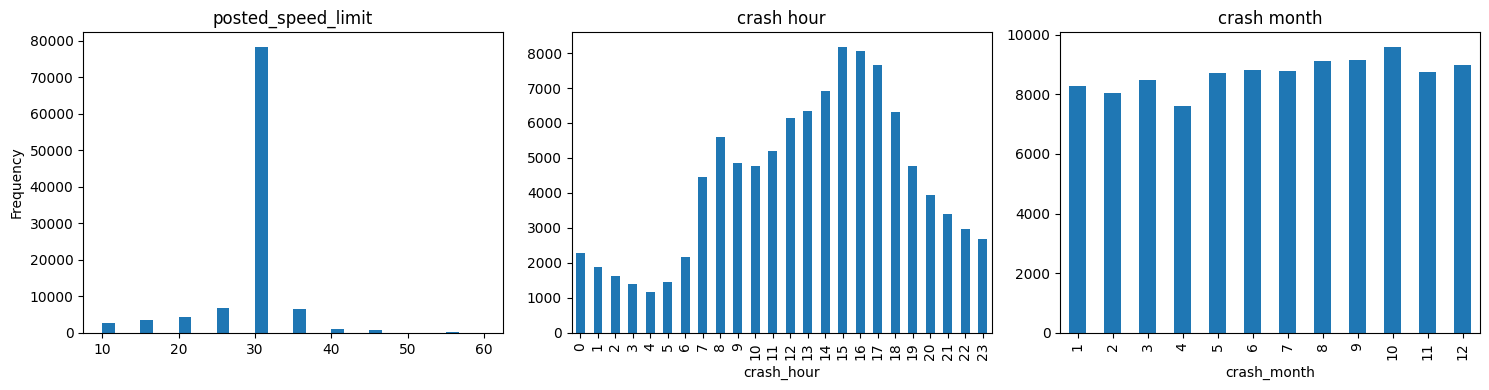

In [55]:
# frequency dsitributions for 'posted_speed_limit', 'crash hour', and 'crash month'
fig, axes = plt.subplots(1, 3, figsize = (15, 4))

sample['posted_speed_limit'].plot(kind = 'hist', bins = 30, ax = axes[0])
axes[0].set_title('posted_speed_limit')

sample['crash_hour'].value_counts().sort_index().plot(kind = 'bar', ax = axes[1])
axes[1].set_title('crash hour')

sample['crash_month'].value_counts().sort_index().plot(kind = 'bar', ax = axes[2])
axes[2].set_title('crash month')

plt.tight_layout()
plt.show()

In [56]:
# mean injuries by key categoricals
for col in ['weather_condition', 'lighting_condition', 'road_defect', 'roadway_surface_cond']:
    means = sample.groupby(col)['injuries_total'].mean().sort_values(ascending = False)
    print(f"\nMean injuries_total by {col}:\n{means.to_string()}")


Mean injuries_total by weather_condition:
weather_condition
OTHER              0.248984
RAIN               0.241701
CLOUDY/OVERCAST    0.208155
CLEAR              0.201124
SNOW               0.173360
UNKNOWN            0.058149

Mean injuries_total by lighting_condition:
lighting_condition
DARKNESS, LIGHTED ROAD    0.255290
DAWN                      0.236650
DUSK                      0.209889
DAYLIGHT                  0.186770
DARKNESS                  0.174554
UNKNOWN                   0.044913

Mean injuries_total by road_defect:
road_defect
NO DEFECTS    0.204001
OTHER         0.196262
UNKNOWN       0.162598

Mean injuries_total by roadway_surface_cond:
roadway_surface_cond
WET                0.245446
OTHER              0.225806
DRY                0.203307
ICE                0.188859
SNOW OR SLUSH      0.149813
SAND, MUD, DIRT    0.139535
UNKNOWN            0.086214


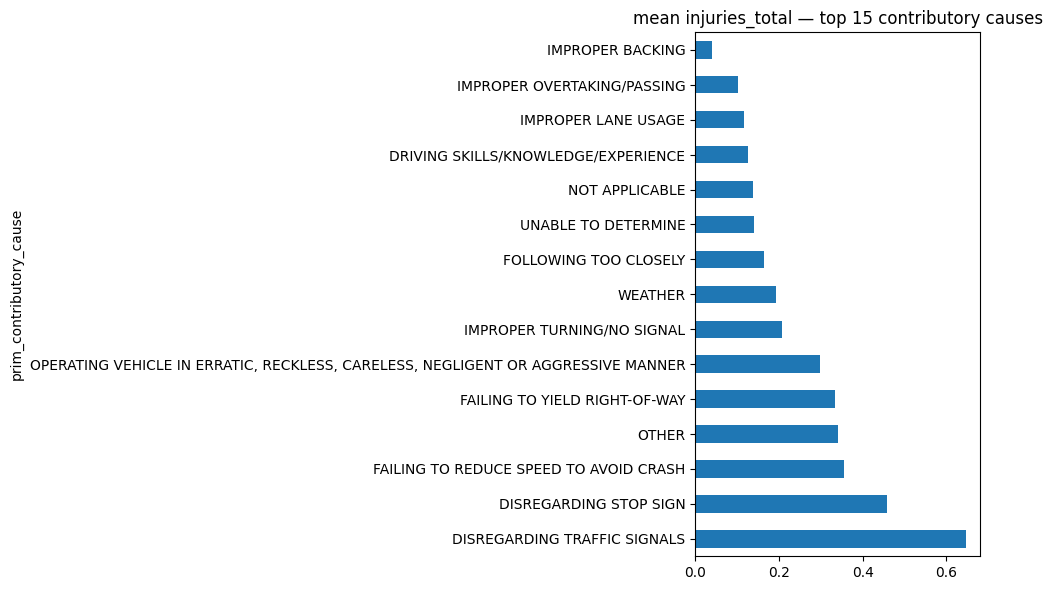

In [57]:
# top 15 most frequent values for 'prim_contributory_cause'
top_causes = sample['prim_contributory_cause'].value_counts().head(15).index
cause_means = (
    sample[sample['prim_contributory_cause'].isin(top_causes)]
    .groupby('prim_contributory_cause')['injuries_total']
    .mean()
    .sort_values(ascending=False)
)

cause_means.plot(kind = 'barh', figsize = (10, 6))
plt.title('mean injuries_total — top 15 contributory causes')
plt.tight_layout()
plt.show()

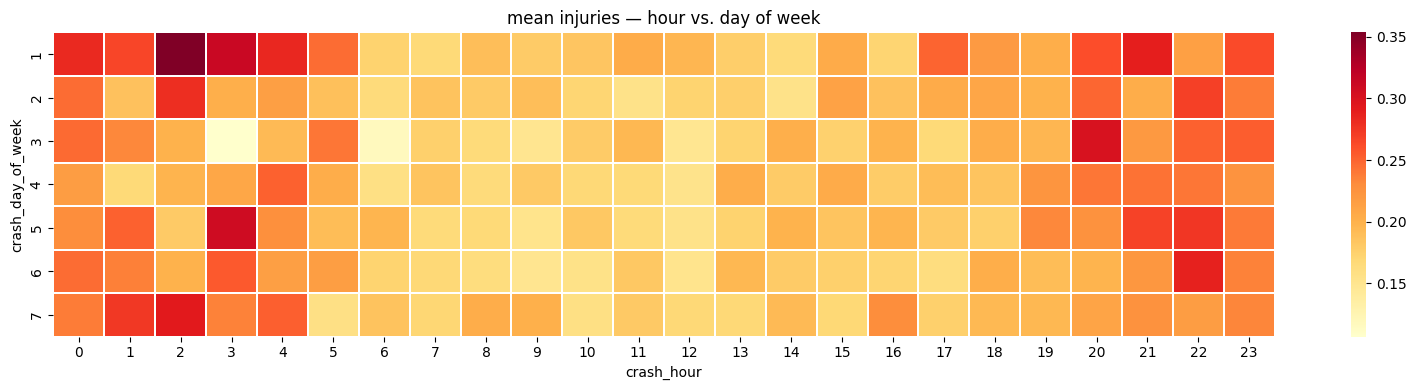

In [58]:
# crash hour × day_of_week heatmap
pivot = sample.pivot_table(
    values = 'injuries_total',
    index = 'crash_day_of_week',
    columns = 'crash_hour',
    aggfunc = 'mean'
)

plt.figure(figsize = (16, 4))
sns.heatmap(pivot, cmap = 'YlOrRd', linewidths = 0.3)
plt.title('mean injuries — hour vs. day of week')
plt.tight_layout()
plt.show()

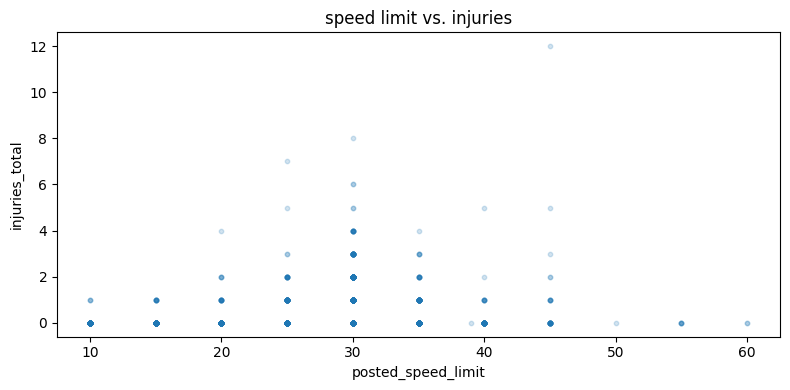

In [59]:
# speed limit scatter (using an even smaller sample of 5000 to avoid overplotting)
mini = sample.sample(5000, random_state = 42)
plt.figure(figsize = (8, 4))
plt.scatter(mini['posted_speed_limit'], mini['injuries_total'], alpha = 0.2, s = 10)
plt.xlabel('posted_speed_limit')
plt.ylabel('injuries_total')
plt.title('speed limit vs. injuries')
plt.tight_layout()
plt.show()

In [60]:
# null rates
null_rates = sample.isnull().mean().sort_values(ascending = False)
print("Null rates:\n", null_rates[null_rates > 0].to_string())

# speed limit anomalies
print("\nSpeed limit value counts (suspicious values):")
print(sample['posted_speed_limit'].value_counts().sort_index().to_string())

# injury outliers
print("\nHigh injury crashes (injuries_total > 10):")
print(sample[sample['injuries_total'] > 10][['crash_record_id','injuries_total','injuries_fatal','prim_contributory_cause']].head(20))

# duplicate IDs
dup_count = sample['crash_record_id'].duplicated().sum()
print(f"\nDuplicate crash_record_ids in sample: {dup_count}")

# BAC and physical_condition coverage (person-level join cols)
for col in ['bac_result', 'physical_condition']:
    missing = sample[col].isna().mean() if col in sample.columns else 'not in df'
    print(f"{col} missing: {missing}")

Null rates:
 Series([], )

Speed limit value counts (suspicious values):
posted_speed_limit
10     2576
11        1
12        1
14        1
15     3561
20     4376
22        2
24        2
25     6861
26        1
30    78340
32        4
33        1
34        1
35     6632
36        1
39       11
40     1052
45      711
50       28
55      109
60        7

High injury crashes (injuries_total > 10):
                                          crash_record_id  injuries_total  \
211269  33efedbd327a3e5deb00e2be281787167c005aedad754b...            11.0   
24666   060d8d00497f986f7184becaaf7d7012a9a10593aa55ca...            11.0   
934676  e5c19f5b96519f52ee7b663907e883aaf5017d839034ff...            12.0   

        injuries_fatal        prim_contributory_cause  
211269             0.0  FAILING TO YIELD RIGHT-OF-WAY  
24666              0.0            UNABLE TO DETERMINE  
934676             0.0   DISREGARDING TRAFFIC SIGNALS  

Duplicate crash_record_ids in sample: 37
bac_result missing: not i